In [13]:
import gymnasium as gym

from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
from stable_baselines3.common.evaluation import evaluate_policy

from pprint import pprint
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
    public_config_summary,
)

np.set_printoptions(suppress=True)

In [ ]:
ROLL_NUMBER = "DA25M622"

student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print("Assigned configuration generated successfully.")
for key, value in config_summary.items():
    print(f"{key}: {value}")

In [14]:
env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

observation, info = env.reset(seed=2026)

print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
pprint(info)
# print("Variant:", info["variant_id"])
# print("Scenario components:", info["episode_parameters"]["scenario_components"])
# print("Episode demand multipliers:", info["episode_parameters"]["demand_multipliers"])
# print("Episode initial inventory:", info["episode_parameters"]["initial_inventory"])
# print("Episode delay probabilities:", info["episode_parameters"]["delay_probabilities"])

Action space: MultiDiscrete([11 11 11])
Observation space: Dict('arrival_pipeline': Box(0, 10000, (3, 4), int32), 'capacity_utilisation': Box(0.0, 1.0, (1,), float32), 'day': Box(0, 50, (1,), int32), 'demand_history': Box(0, 10000, (7, 3), int32), 'inventory': Box(0, 1000, (3,), int32))
{'config_fingerprint': '7d77fc79debf206a',
 'episode_parameters': {'delay_probabilities': [0.08, 0.0, 0.05],
                        'demand_multipliers': [1.05, 1.05, 0.85],
                        'initial_inventory': [110, 100, 90],
                        'scenario_components': ['seasonal', 'trend'],
                        'scenario_details': {'seasonal_amplitudes': [0.06241472342761341,
                                                                     0.09569493618795924,
                                                                     0.07088119371488985],
                                             'trend_direction': 'up',
                                             'trend_total_change'

In [4]:
for key, value in observation.items():
    print(f"{key:22s} shape={value.shape}, dtype={value.dtype}")
    print(value)
    print()

inventory              shape=(3,), dtype=int32
[110 100  90]

arrival_pipeline       shape=(3, 4), dtype=int32
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

demand_history         shape=(7, 3), dtype=int32
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

day                    shape=(1,), dtype=int32
[0]

capacity_utilisation   shape=(1,), dtype=float32
[0.655]



In [ ]:
# env = gym.make("CartPole-v1", render_mode="rgb_array")          # NOTE: CartPole-v1 env requires pygame lib (for vec_env.render() in loop)
# https://stable-baselines3.readthedocs.io/en/master/guide/quickstart.html

In [16]:
# TRAINING
# You must use `MultiInputPolicy` when working with dict observation space, not MlpPolicy
model = A2C("MultiInputPolicy", env, verbose=1)
a = model.learn(total_timesteps=10_000)
a

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 50        |
|    ep_rew_mean        | -8.11e+03 |
| time/                 |           |
|    fps                | 358       |
|    iterations         | 100       |
|    time_elapsed       | 1         |
|    total_timesteps    | 500       |
| train/                |           |
|    entropy_loss       | -6.77     |
|    explained_variance | 1.25e-05  |
|    learning_rate      | 0.0007    |
|    n_updates          | 99        |
|    policy_loss        | -5.31e+03 |
|    value_loss         | 8.91e+05  |
-------------------------------------
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 50        |
|    ep_rew_mean        | -8.72e+03 |
| time/                 |           |
|    fps                | 383       |
|    iterations         | 200   

In [18]:
env.__dict__

{'student_config': {'project_version': 'IITM-6002W-RL-Inventory-2026-v1',
  'roll_number': 'DA25M622',
  'variant_id': 'V022',
  'demand_multiplier_profile': [1.0, 1.1, 0.9],
  'initial_inventory_profile': [110, 100, 90],
  'lead_time_delay_profile': [0.1, 0.0, 0.05],
  'declared_ranges': {'demand_multiplier': [0.85, 1.15],
   'initial_inventory': [80, 120],
   'lead_time_delay_probability': [0.0, 0.1]},
  'config_fingerprint': '7d77fc79debf206a'},
 'scenario_mode': 'random',
 'domain_randomization': True,
 'action_space': MultiDiscrete([11 11 11]),
 'observation_space': Dict('arrival_pipeline': Box(0, 10000, (3, 4), int32), 'capacity_utilisation': Box(0.0, 1.0, (1,), float32), 'day': Box(0, 50, (1,), int32), 'demand_history': Box(0, 10000, (7, 3), int32), 'inventory': Box(0, 1000, (3,), int32)),
 'day': 0,
 'inventory': array([100, 110,  90]),
 'arrival_pipeline': array([[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]),
 'demand_history': array([[0, 0, 0],
        [0, 0, 0],

In [ ]:
model.save("a2c_industrial_inventory")         # saves model to a2c_industrial_inventory.zip in current working directory
env.close()
del model, env

In [ ]:
# NOTE: there must not be a folder of same name or it will get confused - ie if extracting zip for debug, make sure to rename the folder.
loaded_model = A2C.load("a2c_industrial_inventory", print_system_info=True)  # loads model from a2c_industrial_inventory.zip in current working directory

== CURRENT SYSTEM INFO ==
- OS: Linux-7.0.0-30-generic-x86_64-with-glibc2.43 # 30-Ubuntu SMP PREEMPT_DYNAMIC Fri Jul 31 18:22:54 UTC 2026
- Python: 3.12.13
- Stable-Baselines3: 2.9.0
- PyTorch: 2.13.0+cpu
- GPU Enabled: False
- Numpy: 2.5.2
- Cloudpickle: 3.1.2
- Gymnasium: 1.3.0

== SAVED MODEL SYSTEM INFO ==
- OS: Linux-7.0.0-30-generic-x86_64-with-glibc2.43 # 30-Ubuntu SMP PREEMPT_DYNAMIC Fri Jul 31 18:22:54 UTC 2026
- Python: 3.12.0
- Stable-Baselines3: 2.9.0
- PyTorch: 2.13.0+cpu
- GPU Enabled: False
- Numpy: 2.5.2
- Cloudpickle: 3.1.2
- Gymnasium: 1.3.0



In [3]:
loaded_model

In [11]:
rewards, episode_lengths = evaluate_policy(loaded_model, env, n_eval_episodes=20, return_episode_rewards=True)
print(rewards)
print(episode_lengths)

[np.float64(-15939.599979400635), np.float64(-16315.624977111816), np.float64(-17444.725036621094), np.float64(-17036.77497959137), np.float64(-17205.90003633499), np.float64(-15059.950080871582), np.float64(-15860.674951553345), np.float64(-16336.000049591064), np.float64(-17347.15000152588), np.float64(-15127.474964141846), np.float64(-17109.549967765808), np.float64(-16843.575107574463), np.float64(-16509.449862480164), np.float64(-15218.274868011475), np.float64(-15894.724988937378), np.float64(-17032.675117492676), np.float64(-16901.0749168396), np.float64(-16588.600006103516), np.float64(-16744.79999065399), np.float64(-17328.64985179901)]
[np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50), np.int64(50)]


In [19]:
episode_costs = [-r * 100 for r in rewards]
print("Episode costs:", episode_costs)

Episode costs: [np.float64(1593959.9979400635), np.float64(1631562.4977111816), np.float64(1744472.5036621094), np.float64(1703677.497959137), np.float64(1720590.0036334991), np.float64(1505995.0080871582), np.float64(1586067.4951553345), np.float64(1633600.0049591064), np.float64(1734715.000152588), np.float64(1512747.4964141846), np.float64(1710954.9967765808), np.float64(1684357.5107574463), np.float64(1650944.9862480164), np.float64(1521827.4868011475), np.float64(1589472.4988937378), np.float64(1703267.5117492676), np.float64(1690107.49168396), np.float64(1658860.0006103516), np.float64(1674479.9990653992), np.float64(1732864.9851799011)]


In [12]:
len(rewards), len(episode_lengths)

(20, 20)

In [10]:
mean_return_per_episode, std_reward_per_episode = evaluate_policy(loaded_model, env, n_eval_episodes=20)
print(mean_return_per_episode)
print(std_reward_per_episode)

-16114.279968094826
567.4863621117698


In [26]:
# manual eval loop for 1 episode, to get the info dict for each step, to get the costs
records = []
observation, info = env.reset(seed=101)
while True:
    action, _ = loaded_model.predict(observation, deterministic=True)  # MultiDiscrete indices directly
    observation, reward, terminated, truncated, info = env.step(action)
    records.append({
        "action": action,
        "reward": reward,
        "truncated": truncated,
        "info": info,
        'day': info['day'],
        **info['costs']
    })
    if terminated or truncated:
        break

df = pd.DataFrame(records)
df

,action,reward,truncated,info,day,holding,stockout,ordering,discarding,daily_total,episode_total
0,"[8, 1, 0]",-27.05,False,"{'day': 0, 'demand': [25, 21, 28], 'fulfilled_...",0,2425.0,0.0,280.0,0.0,2705.0,2705.0
1,"[7, 1, 0]",-19.35,False,"{'day': 1, 'demand': [23, 19, 34], 'fulfilled_...",1,1655.0,0.0,280.0,0.0,1935.0,4640.0
2,"[9, 8, 0]",-10.95,False,"{'day': 2, 'demand': [33, 30, 28], 'fulfilled_...",2,815.0,0.0,280.0,0.0,1095.0,5735.0
3,"[7, 2, 0]",-62.90,False,"{'day': 3, 'demand': [36, 26, 20], 'fulfilled_...",3,210.0,5800.0,280.0,0.0,6290.0,12025.0
4,"[7, 2, 0]",-128.45,False,"{'day': 4, 'demand': [23, 21, 34], 'fulfilled_...",4,2365.0,10200.0,280.0,0.0,12845.0,24870.0
5,"[7, 2, 0]",-140.30,False,"{'day': 5, 'demand': [27, 43, 37], 'fulfilled_...",5,2650.0,11100.0,280.0,0.0,14030.0,38900.0
6,"[9, 1, 0]",-137.90,False,"{'day': 6, 'demand': [19, 30, 35], 'fulfilled_...",6,3010.0,10500.0,280.0,0.0,13790.0,52690.0
7,"[9, 1, 0]",-140.15,False,"{'day': 7, 'demand': [25, 35, 35], 'fulfilled_...",7,3235.0,10500.0,280.0,0.0,14015.0,66705.0
8,"[9, 1, 0]",-99.75,False,"{'day': 8, 'demand': [33, 24, 21], 'fulfilled_...",8,3395.0,6300.0,280.0,0.0,9975.0,76680.0
9,"[9, 1, 0]",-167.20,False,"{'day': 9, 'demand': [29, 30, 27], 'fulfilled_...",9,3840.0,12600.0,280.0,0.0,16720.0,93400.0


<Axes: >

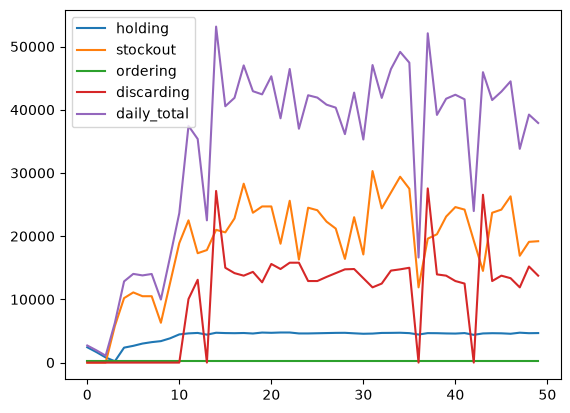

In [25]:
df[['holding', 'stockout', 'ordering', 'discarding', 'daily_total']].plot()      # , 'episode_total'